LIMPIEZA DE DATOS


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


FILAS DE DATA SET

In [ ]:
import pandas as pd

df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns)

Dimensiones del dataset:
(768, 9)

Columnas:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


Número de filas y columnas

In [ ]:
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(768, 9)


Valores nulos

In [ ]:
print("Valores faltantes:")
df.isnull().sum()

Valores faltantes:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Cantidad de duplicados

In [ ]:
duplicados = df.duplicated().sum()

print("Registros duplicados:")
print(duplicados)

Registros duplicados:
0


Tamaño después de eliminar duplicados

In [ ]:
df = df.drop_duplicates()

print("Nuevo tamaño:")
print(df.shape)

Nuevo tamaño:
(768, 9)


Tipos de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Estadísticas descriptivas

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


ANÁLISIS EXPLORATORIO

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Distribución de Diabetes

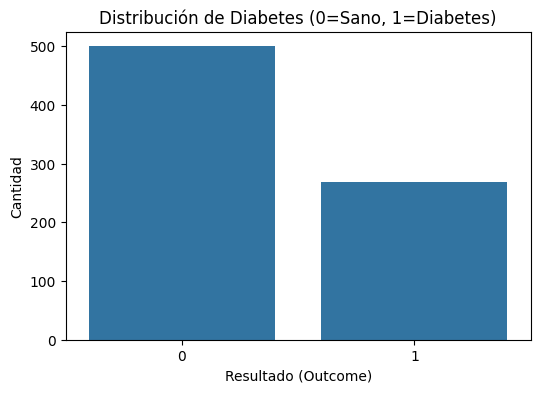

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

# Usamos 'Outcome' que es el nombre real en tu archivo actual
sns.countplot(x='Outcome', data=df)

plt.title('Distribución de Diabetes (0=Sano, 1=Diabetes)')
plt.xlabel('Resultado (Outcome)')
plt.ylabel('Cantidad')

plt.show()

Distribución por Edad

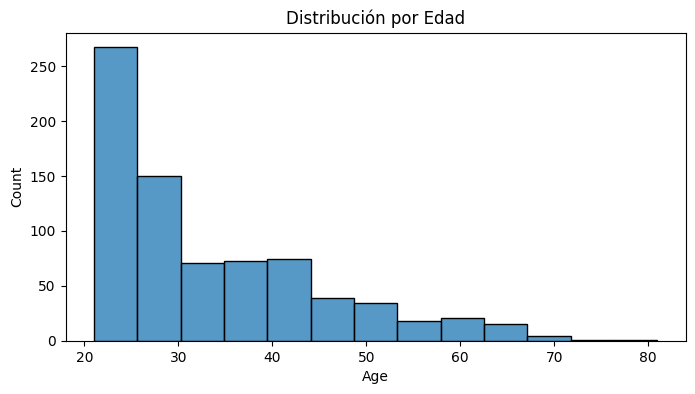

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(df['Age'], bins=13)

plt.title('Distribución por Edad')
plt.show()

Distribución del IMC

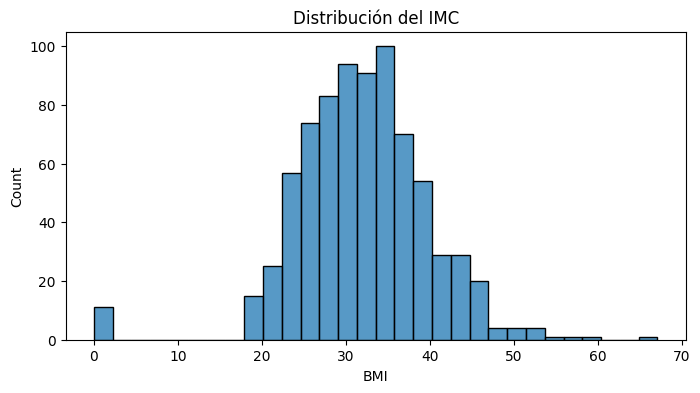

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(df['BMI'], bins=30)

plt.title('Distribución del IMC')
plt.show()

Matriz de correlación

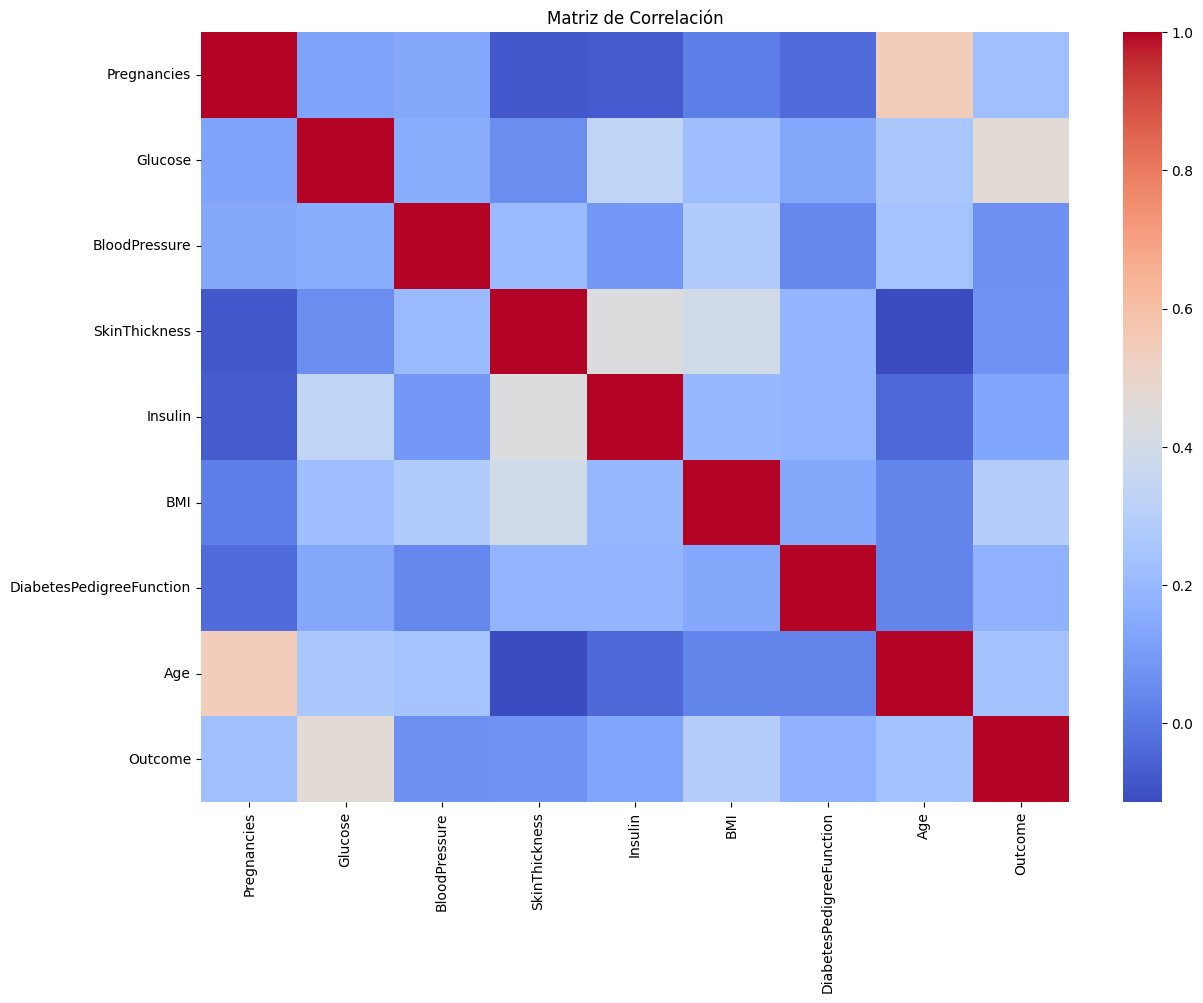

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Matriz de Correlación')
plt.show()

DIVISIÓN DE DATOS

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

KeyError: "['Diabetes_012'] not found in axis"

NORMALIZACIÓN

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Normalización completada")

Normalización completada


DESBALANCE (SMOTE)

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Antes:", y_train.value_counts())

print("\nDespués:")

from collections import Counter
print(Counter(y_train_smote))

Antes: Diabetes_012
0.0    151939
2.0     28162
1.0      3723
Name: count, dtype: int64

Después:
Counter({0.0: 151939, 2.0: 151939, 1.0: 151939})


Implementación del Modelo


In [ ]:
!pip install tensorflow

Entrenamiento del Modelo


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(21,)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587 (14.01 KB)

 Trainable params: 3,587 (14.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_smote,
    y_train_smote,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
11396/11396 ━━━━━━━━━━━━━━━━━━━━ 68s 5ms/step - accuracy: 0.5801 - loss: 0.8954 - val_accuracy: 0.0510 - val_loss: 1.5482
Epoch 2/20
11396/11396 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.6009 - loss: 0.8670 - val_accuracy: 0.0509 - val_loss: 1.5616
Epoch 3/20
11396/11396 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.6083 - loss: 0.8574 - val_accuracy: 0.1067 - val_loss: 1.4797
Epoch 4/20
11396/11396 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.6133 - loss: 0.8502 - val_accuracy: 0.1233 - val_loss: 1.4624
Epoch 5/20
11396/11396 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.6163 - loss: 0.8460 - val_accuracy: 0.1054 - val_loss: 1.5136
Epoch 6/20
11396/11396 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.6193 - loss: 0.8420 - val_accuracy: 0.1401 - val_loss: 1.4311
Epoch 7/20
11396/11396 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.6203 - loss: 0.8389 - val_accuracy: 0.1208 - val_loss: 1.4859
Epoch 8/20
11396/11396 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 

Curva de Precisión


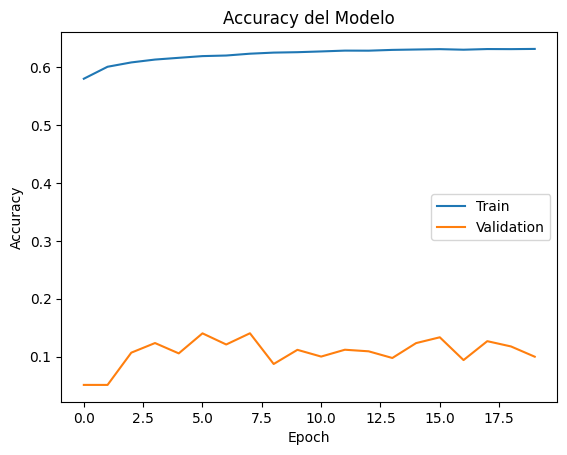

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy del Modelo')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

Curva de Pérdida


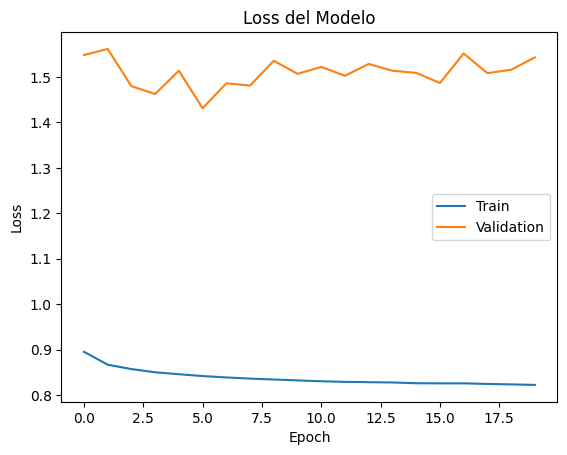

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss del Modelo')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

Evaluación del Modelo


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

1437/1437 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6029 - loss: 0.7838
Accuracy: 0.6028896570205688


Matriz de Confusión


1437/1437 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


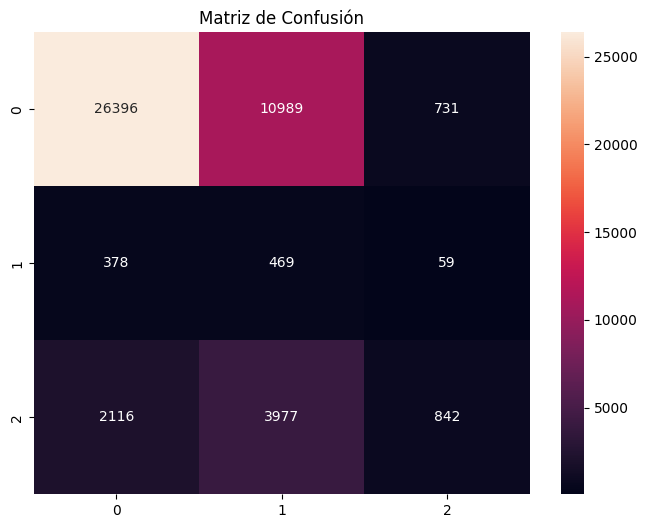

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

y_pred = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Matriz de Confusión')

plt.show()

Métricas de Desempeño


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.69      0.79     38116
         1.0       0.03      0.52      0.06       906
         2.0       0.52      0.12      0.20      6935

    accuracy                           0.60     45957
   macro avg       0.49      0.44      0.35     45957
weighted avg       0.84      0.60      0.68     45957



In [ ]:
model.save("modelo_diabetes.h5")

In [ ]:
model.save("modelo_diabetes.keras")

In [ ]:
import os

os.listdir()

['.config',
 'modelo_diabetes.keras',
 'modelo_diabetes.h5',
 'diabetes_012_health_indicators_BRFSS2015 (1).csv',
 'diabetes_012_health_indicators_BRFSS2015.csv',
 'sample_data']

In [ ]:
from google.colab import files

files.download("modelo_diabetes.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>